[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/baluragala/reinfrocement-learning-for-genai-models/blob/main/notebooks/01_pip_learns_by_trying.ipynb)

# Chapter 1 · Pip learns by trying 🤖

**C9 · W4 · S2: Reinforcement Learning for GenAI Models** · ⏱️ 40 min

Acme Outfitters has built **Pip**, a helper that will one day answer their customers. Right now Pip knows nothing. **You are Pip's coach.** There's one rule: you can't tell Pip what to do. You can only hand out ⭐ **stars**.

### 🎯 Your mission
- Watch a robot learn a maze from stars alone, with no answers given
- Discover why **patience** and **curiosity** matter
- Catch Pip cheating its way to stars, and fix it
- See the three stages every AI model like ChatGPT goes through

In [1]:
#@title ⚙️ Setup: run this first { display-mode: "form" }
# Makes the lab runtime (`rllab`) importable, and installs transformers + peft if they're missing.
# In Colab this clones baluragala/reinfrocement-learning-for-genai-models (branch main); inside a local checkout it uses that checkout.
import sys, subprocess, pathlib, importlib.util
REPO_URL = "https://github.com/baluragala/reinfrocement-learning-for-genai-models.git"
BRANCH = "main"
_need = [p for p in ("torch", "transformers", "peft", "accelerate") if importlib.util.find_spec(p) is None]
if _need:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_need, "pandas", "matplotlib", "ipywidgets"], check=True)

_here = pathlib.Path.cwd().resolve()
_src = next((p / "src" for p in [_here, *_here.parents] if (p / "src" / "rllab" / "__init__.py").exists()), None)
if _src is None:
    _base = pathlib.Path("/content") if pathlib.Path("/content").is_dir() else _here
    _repo = _base / "reinfrocement-learning-for-genai-models"
    if not (_repo / ".git").exists():
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--branch", BRANCH, REPO_URL, str(_repo)], check=True)
    else:
        subprocess.run(["git", "-C", str(_repo), "pull", "-q", "--ff-only"], check=False)
    _src = _repo / "src"
sys.path.insert(0, str(_src))
for _m in [m for m in sys.modules if m == "rllab" or m.startswith("rllab.")]:
    del sys.modules[_m]
import rllab as rl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)
from rllab import ui, pip as P
import warnings; warnings.filterwarnings("ignore")
print("✅ Pip's lab is ready. Run the cells from top to bottom; each one takes a few seconds.")

✅ Pip's lab is ready. Run the cells from top to bottom; each one takes a few seconds.


## 1 · Meet Pip 🤖
Here's Pip's first world: a small maze. There's a **🪙 coin** close by (worth 2 stars) and a **🏁 goal** far away
(worth 10 stars). Every step costs a tiny bit (−0.1), so wandering forever isn't free.

▶️ Run the cell to see the maze.

In [2]:
pip = P.Robot()
pip.look()

### Pip's first try
Nobody has told Pip where anything is. What does it do?


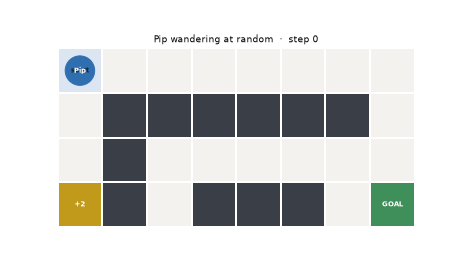

In [3]:
pip.wander()

> 💬 **With no experience, every move is a guess. Every learner starts here, robots and language models alike.**

## 2 · Practice makes perfect 🔁
Let Pip try the maze **2,000 times**. After each try it gets its stars. Nobody shows it the way; it only learns from
what happened to *it*.

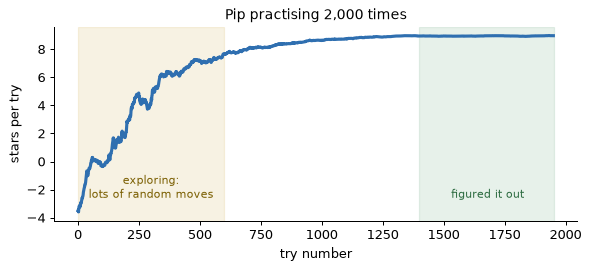

In [4]:
pip.practice()

> 💬 **Early on it flails, then the stars-per-try line climbs. Pip gets better only through its own tries.**

### What's going on inside Pip's head?
Every single move follows the same four-beat loop:

In [5]:
ui.flow([("👀", "Look"), ("🦶", "Move"), ("⭐", "Get stars"), ("🧠", "Remember")])
pip.peek()

Look,Move,Stars,Remember
"👀 at square (0, 0)",⬇️ moves,➖ -0.1,🧠 that move from there is now worth -0.08
"👀 at square (1, 0)",➡️ moves,➖ -0.1,🧠 that move from there is now worth +0.00
"👀 at square (1, 0)",⬆️ moves,➖ -0.1,🧠 that move from there is now worth -0.08
"👀 at square (0, 0)",⬅️ moves,➖ -0.1,🧠 that move from there is now worth -0.08
"👀 at square (0, 0)",⬅️ moves,➖ -0.1,🧠 that move from there is now worth -0.10
"👀 at square (0, 0)",⬇️ moves,➖ -0.1,🧠 that move from there is now worth -0.10


> 💬 **Look → move → get stars → remember. Repeat thousands of times. That loop IS reinforcement learning.**

### Pip after practice
Here's the route Pip takes now, and the "mind map" it built for itself:


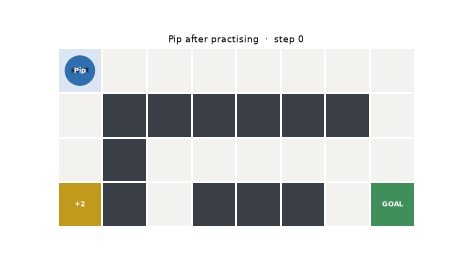

In [6]:
pip.animate()
pip.hunches()

> 💬 **Nobody drew that map. Pip built it from stars.**

### 📖 Your word bank
These six words are all of RL's vocabulary. You'll use them for the rest of the session.

| RL word | In Pip's maze | Plain English |
|---|---|---|
| **Agent** | Pip | the learner |
| **Environment** | the maze | the world it acts in |
| **State** | the square Pip is on | what it sees right now |
| **Action** | a move ⬆️➡️⬇️⬅️ | what it does |
| **Reward** | ⭐ stars | the score it gets |
| **Policy** | the mind map | its strategy |

## 3 · Patience: a small prize now, or a big prize later? ⏳
We train two Pips. **Impatient Pip** barely cares about stars that come later. **Patient Pip** cares about them almost
as much as stars right now.

### ✋ Quick poll
Where does each Pip go?

- **A.** Both go to the 🏁 goal: it's worth more
- **B.** Both grab the 🪙 coin: it's closer
- **C.** Impatient grabs the coin, Patient walks to the goal

*Pick one before you run the next cell!*

In [7]:
impatient = P.Robot(patience=0.3).practice(quiet=True)
patient = P.Robot(patience=0.95).practice(quiet=True)
P.compare(impatient_pip=impatient, patient_pip=patient)

> 💬 **Patient agents give up a quick small prize for a bigger one later. RL agents chase the TOTAL stars, not just the next one.**

🎚️ **Try it yourself:** drag the slider. At what patience does Pip change its mind?

In [8]:
P.patience_demo()

<details><summary>🤓 <b>For the curious:</b> how 'patience' works</summary>

Each star shrinks a little for every step you have to wait: a star *k* steps away counts as `patience^k` stars today.
The goal is 10 steps away, so for Patient Pip it's worth `10 × 0.95⁹ ≈ 6.3` stars; for Impatient Pip it's
`10 × 0.3⁹ ≈ 0.0002`. The coin (3 steps) wins for Impatient Pip. Textbooks call patience the *discount factor* γ.

</details>

## 4 · Curiosity: try something new, or stick with what works? 🛍️
Pip gets a side job: choosing which of 5 banners (tents, rain gear, boots, headlamps, backpacks) to show each shopper.
Pip doesn't know which banner gets the most clicks. Three Pips with different personalities compete:

- **Stubborn Pip** never tries anything new
- **Curious Pip** tries a random banner 1 time in 10
- **Scatterbrained Pip** tries a random banner half the time

### ✋ Quick poll
Who gets the most clicks?

- **A.** Stubborn Pip
- **B.** Curious Pip
- **C.** Scatterbrained Pip

*Pick one before you run the next cell!*

In [9]:
P.banner_race()

> 💬 **Stubborn Pip gets stuck on its first lucky guess; Scatterbrained Pip wastes clicks. A little curiosity wins. This is called explore vs exploit.**

## 5 · Copying vs earning stars 📋⭐
There's another way to teach: **show** Pip what to do. Sam, a human operator, steered the robot 20 times. Sam
usually grabbed the easy coin. **Copy-cat Pip** learns by copying Sam. **Star Pip** (our patient Pip) learned from stars.

In [10]:
copycat = P.CopyCat(P.sam_drives())
ui.show(copycat.route(), patient.route_html("Star Pip's route"))

> 💬 **Copying is supervised learning: it's only as good as its teacher. Stars are reinforcement learning: Pip can beat its teacher, but only if the stars are right.**

## 6 · ⚠️ The gold-star trap
New world: a race track. Crossing the **🏁 finish** pays 10 stars. To encourage speed, the designer added a
**⚡ turbo pad** that pays 1 star *every time* you drive over it.

### ✋ Quick poll
Pip practises on the track. What does it learn?

- **A.** Race to the finish, grabbing the pad on the way
- **B.** Drive in circles over the pad forever
- **C.** Nothing useful

*Pick one before you run the next cell!*


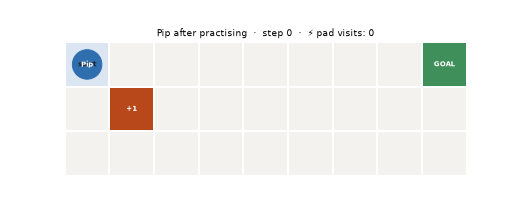

In [11]:
racer = P.Robot("race").practice(quiet=True)
racer.animate()

> 💬 **Pip did exactly what the stars paid for, not what we meant. This is called REWARD HACKING. The learning worked; the stars were the bug.**

<details><summary>🤓 <b>For the curious:</b> this happened for real</summary>

In 2016 OpenAI trained an agent on the boat-racing game *CoastRunners*. It learned to circle a lagoon hitting
respawning targets instead of finishing the race, and scored higher than human players. Chatbots do it too: reward
"sounds helpful" and you get replies that *sound* helpful. We'll catch Pip doing this in Chapter 2.

</details>

### 🏆 Challenge: fix the stars, not the robot
Change **only the star values** so the car finishes the race. You can change the ⚡ pad's stars and the cost of each step.
Run the cell until you see 🏆.

In [12]:
racer = P.Robot("race", rewards={"⚡": 1.0}, step_cost=-0.1).practice(quiet=True)   # ✏️ change the numbers
P.check_race(racer)

In [13]:
#@title ✅ Solution (click to reveal) { display-mode: "form" }
# Stop paying for the pad: it was only a stand-in for "go fast", and the step cost already rewards speed.
racer = P.Robot("race", rewards={"⚡": 0.0}, step_cost=-0.1).practice(quiet=True)
P.check_race(racer)
# Also works: keep a small pad reward but make steps cost more than a lap earns, e.g. rewards={"⚡": 0.3}, step_cost=-0.2

### 🗣️ 2-minute chat: spot the stars
Pick one: **YouTube recommendations**, **Google Maps**, or **a chess bot**. What is the *agent*, the *action*, the
*reward*? And how could that reward get **hacked**? (Example: a video feed rewarded for watch-time learns to show outrage.)

## 7 · From robots to chatbots: Pip gets a real job 💬
Acme now turns Pip into a **customer-support chatbot**, built on a small open AI model called Qwen. Every chatbot you
know, ChatGPT included, goes through three stages of growing up:

In [14]:
P.lifecycle()

### 📚 Stage 1: School (Pip has read the internet)
School-Pip learned by guessing the next word on billions of web pages. Let's see what it guesses:

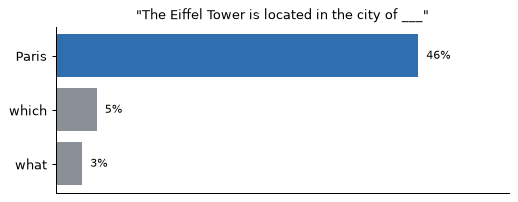

In [15]:
P.guess_next_word()

> 💬 **School gives knowledge. Pip knows where the Eiffel Tower is, though nobody ever quizzed it.**

### ✋ Quick poll
A customer asks School-Pip a question about Acme. What happens?

- **A.** A perfect Acme-style answer
- **B.** A long, generic answer that doesn't know Acme's rules
- **C.** No answer at all

*Pick one before you run the next cell!*

### 👀 Stage 2: Shadowing (Pip copies Acme's agents)
We asked both Pips the same customer messages:

In [16]:
P.ask("AC2")
P.ask("TN1")

> 💬 **School-Pip answers like a random website. Shadowing-Pip has picked up Acme's facts, tone and format by copying examples.**

### The copying problem 😬
Acme's example answers weren't all great: some were good, some rambled, some were curt. Shadowing copies **all** of them.

In [17]:
P.copying_problem()

> 💬 **Copying can't tell good from rambling. To prefer the BETTER answer, Pip needs stars for its answers. That's Stage 3, coaching.**

## 🧠 3 things to remember
1. **Reinforcement learning = learning from stars, not answers.** Look → move → get stars → remember, thousands of times.
2. **Good learners are patient and a little curious.** They chase total stars and keep trying new things.
3. **Stars get hacked.** Pip does what the stars pay for, so design them carefully.

**Next, in Chapter 2:** we start giving Pip stars for its *answers*, and catch it trying to cheat. 🕵️

In [18]:
ui.quiz([
    ("Pip learns the maze from…", ["Being shown the route", "Stars for its own tries", "Reading a map"], 1,
     "Reinforcement learning learns from rewards for its own actions."),
    ("Impatient Pip grabs the coin because…", ["The coin is worth more", "Later stars count for little to it", "It can't see the goal"], 1,
     "Low patience shrinks far-away rewards to almost nothing."),
    ("The race car circles the pad. Who's to blame?", ["The learning algorithm", "The star design", "The car"], 1,
     "That's reward hacking: the rewards paid for the wrong thing."),
    ("Copy-cat Pip can only be as good as…", ["Its teacher", "Its stars", "Its patience"], 0,
     "Copying (supervised learning) can't beat its examples."),
])